# Experiment: Baseline MLP

Calls the training pipeline with a fixed config. Change the config dict to run a new experiment.

In [1]:
import sys, os

if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    REPO_URL = 'https://github.com/byambaa0325/diabetes-uci-dataset.git'
    if not os.path.exists(REPO):
        os.system(f'git clone {REPO_URL}')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
    os.system('pip install -q -e .')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [2]:
import torch
from src.data.loader import load_raw
from src.data.preprocessor import clean, encode_target
from src.data.features import build_features
from src.models.trainers import run_training
from src.evaluation.metrics import evaluate

In [3]:
# --- Data ---
df_raw, _ = load_raw()
df = encode_target(clean(df_raw))

# Temporal split: keep original row order (encounters are roughly chronological)
split = int(0.8 * len(df))
df_train, df_val = df.iloc[:split].copy(), df.iloc[split:].copy()

# Fit scaler on train only; reuse for val to prevent leakage
X_train, y_train, scaler = build_features(df_train, fit_scaler=True)
X_val,   y_val,   _      = build_features(df_val,   scaler=scaler, fit_scaler=False)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Features: {X_train.shape[1]}')

Train: (57214, 41)  |  Val: (14304, 41)  |  Features: 41


In [4]:
# --- Config: pick one block and run ---

# PyTorch MLP
config = {
    'name':          'baseline_mlp',
    'wandb_project': 'applied-ai-coursework',
    'model':         'mlp',            # see src/models/registry.py for all options
    'input_dim':     X_train.shape[1],
    'hidden_dims':   [128, 64],
    'output_dim':    1,
    'dropout':       0.3,
    'lr':            1e-3,
    'epochs':        50,
    'batch_size':    256,
    'X_train': X_train, 'y_train': y_train,
    'X_val':   X_val,   'y_val':   y_val,
}

# Sklearn — swap in instead of the block above
# config = {
#     'name':          'baseline_logreg',
#     'wandb_project': 'applied-ai-coursework',
#     'model':         'logistic_regression',   # or 'random_forest', 'gradient_boosting'
#     'model_params':  {'C': 1.0, 'max_iter': 1000},
#     'X_train': X_train, 'y_train': y_train,
#     'X_val':   X_val,   'y_val':   y_val,
# }

In [5]:
# Train
run_dir = run_training(config)
print('Artefacts saved to:', run_dir)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\byamb\_netrc.
wandb: Currently logged in as: byambaa-bayarmandakh-25 (byambaa-bayarmandakh-25-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Early stopping at epoch 31  (best val_loss 0.238076)


train_loss,█▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_loss,▅▃█▂▃▅▇▆▄▄▂▄▁▃▃▂▅▃▃▅▁▄▂▆▃▄▁▂▂▂▄
train_loss,0.29695
val_loss,0.24317


Run saved → E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_19-05-48_baseline_mlp
Artefacts saved to: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_19-05-48_baseline_mlp


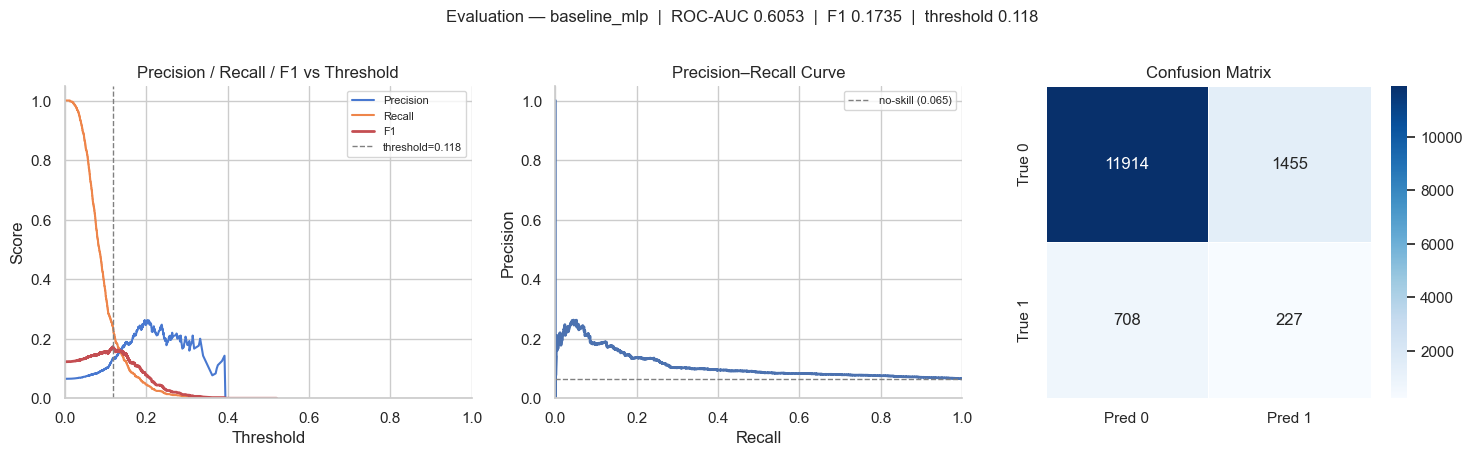

ROC-AUC  : 0.6053
Threshold: 0.118
F1       : 0.1735
Recall   : 0.2428
Precision: 0.1350


In [ ]:
# Evaluate — works for both PyTorch and sklearn
import joblib
from src.models.registry import MODEL_REGISTRY
from src.networks.mlp import MLP

entry = MODEL_REGISTRY[config['model']]

if entry['framework'] == 'torch':
    model = MLP(config['input_dim'], config['hidden_dims'])
    model.load_state_dict(torch.load(run_dir / 'weights.pt', weights_only=True))
else:
    model = joblib.load(run_dir / 'model.joblib')

results = evaluate(model, X_val, y_val, threshold = None, plot=True, title=config['name'])

print(f"ROC-AUC  : {results['roc_auc']:.4f}")
print(f"Threshold: {results['threshold']:.3f}")
print(f"F1       : {results['f1']:.4f}")
print(f"Recall   : {results['recall']:.4f}")
print(f"Precision: {results['precision']:.4f}")